In [9]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import numpy as np
import pandas as pd

ch.set_printoptions(precision=4, sci_mode=False)

In [2]:
import time 

def generate_data(phi, num_samples, M, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
        
    S = ch.Tensor([])
    X = ch.Tensor([])
    sampled = 0
    while S.size(0) < num_samples:
        
        samples = M.sample([num_samples])
        
        trunc_indices = phi(samples).flatten().nonzero().flatten()

        S = ch.cat([S, samples[trunc_indices]])
        sampled += num_samples

    alpha = S.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return S[:num_samples], alpha, X 

# One Dimension - Varying Samples

In [3]:
MU = ch.zeros(1)
SIGMA = ch.ones(1, 1)

M = MultivariateNormal(MU, SIGMA)

# Define truncation region: S = {z > 0}
def phi(x): 
    return x > 0

S, alpha, X = generate_data(phi, 1000, M, verbose=True)

alpha: 0.486


Observed mean (x): [[0.8123601675033569]]


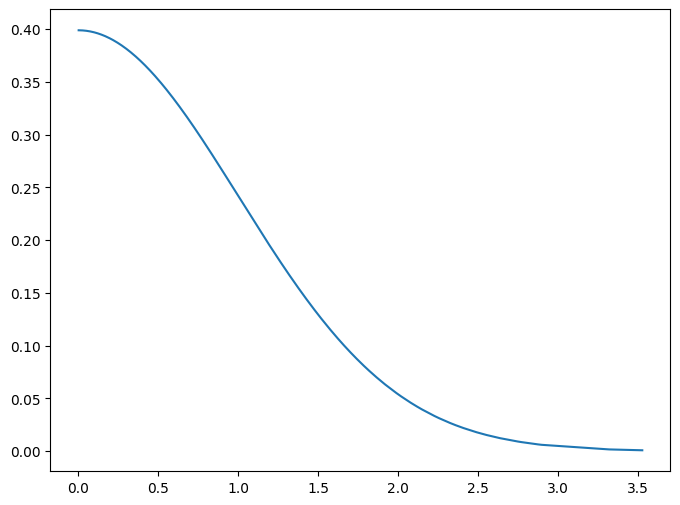

In [5]:
# === Synthetic truncated dataset ===
x_obs = S.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(M.log_prob(sorted_S[...,None]))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)

In [17]:
from delphi.utils.helpers import Parameters
from delphi.distributions import TruncatedMultivariateNormal
from torch.distributions.kl import kl_divergence

def phi(X): 
    return X > 0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 10

results = []

MU, SIGMA = ch.ones(1,), ch.eye(1)
M = MultivariateNormal(MU, SIGMA)

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        S, alpha, X = generate_data(phi, num_samples, M, D=1)

        emp_mu = S.mean(0)
        emp_var = S.var(0, keepdim=True)
        emp_dist = MultivariateNormal(emp_mu, emp_var)
        emp_kl_divergence = kl_divergence(M, emp_dist).item()
            
        args = Parameters({
                            'trials': 1,
                            'batch_size': 10,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
#                             'verbose': True,
        })
        trunc_norm = TruncatedMultivariateNormal(args,
                                                phi,
                                                alpha,
                                                1)
        trunc_norm.fit(S)

        delphi_mu_ = trunc_norm.best_loc_
        delphi_var_ = trunc_norm.best_covariance_matrix_
        delphi_dist = MultivariateNormal(delphi_mu_, delphi_var_)
        delphi_kl_divergence = kl_divergence(M, delphi_dist).item()
        
        result = { 
            'num_samples': num_samples,
            'emp_kl': emp_kl_divergence, 
            'delphi_kl': delphi_kl_divergence, 
        }

        results.append(result)
            
    
df = pd.DataFrame(results)

trial: 1, num samples: 100


/home/patroklos/base/lib/python3.12/site-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


trial: 1, num samples: 500
trial: 1, num samples: 1000
trial: 1, num samples: 2000
trial: 1, num samples: 3000
trial: 1, num samples: 4000
trial: 1, num samples: 5000
trial: 1, num samples: 6000
trial: 1, num samples: 7000
trial: 1, num samples: 8000
trial: 1, num samples: 9000
trial: 1, num samples: 10000
trial: 2, num samples: 100
trial: 2, num samples: 500
trial: 2, num samples: 1000
trial: 2, num samples: 2000
trial: 2, num samples: 3000
trial: 2, num samples: 4000
trial: 2, num samples: 5000
trial: 2, num samples: 6000
trial: 2, num samples: 7000
trial: 2, num samples: 8000
trial: 2, num samples: 9000
trial: 2, num samples: 10000
trial: 3, num samples: 100
trial: 3, num samples: 500
trial: 3, num samples: 1000
trial: 3, num samples: 2000
trial: 3, num samples: 3000
trial: 3, num samples: 4000
trial: 3, num samples: 5000
trial: 3, num samples: 6000
trial: 3, num samples: 7000
trial: 3, num samples: 8000
trial: 3, num samples: 9000
trial: 3, num samples: 10000
trial: 4, num samples:

KeyboardInterrupt: 

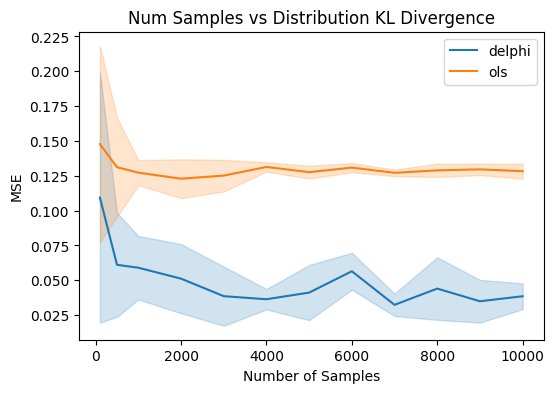

In [19]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_kl", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_kl", estimator="mean", errorbar="sd", ax=ax, label="Empirical")
ax.set_title('Num Samples vs Distribution KL Divergence')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('KL Divergence')

plt.show()